In [2]:
from typing import TypedDict,Literal

from langgraph.constants import START


class portfoliostate(TypedDict):
    amount_usd : float
    total_usd : float
    target_currency : Literal["INR", "EUR"]
    total : float

In [3]:
def cacl_total(state: portfoliostate) -> portfoliostate:
    state['total_usd'] = state['amount_usd'] * 1.08
    return state

def convert_to_inr(state: portfoliostate) -> portfoliostate:
    state['total'] = state['amount_usd'] * 92
    return state

def convert_to_eur(state: portfoliostate) -> portfoliostate:
    state['total'] = state['total_usd'] * 0.9
    return state

def choose_conversion(state: portfoliostate) -> str:
    return state["target_currency"]

In [4]:
from langgraph.graph import StateGraph, START ,END


builder = StateGraph(portfoliostate)

builder.add_node("cal_total", cacl_total)

builder.add_node("convert_to_inr", convert_to_inr)

builder.add_node("convert_to_eur", convert_to_eur)

builder.add_edge(START,"cal_total")
builder.add_conditional_edges("cal_total",
  choose_conversion,
    {
      "INR":"convert_to_inr",
      "EUR":"convert_to_eur",
    })

builder.add_edge("convert_to_inr", END)
builder.add_edge("convert_to_eur", END)




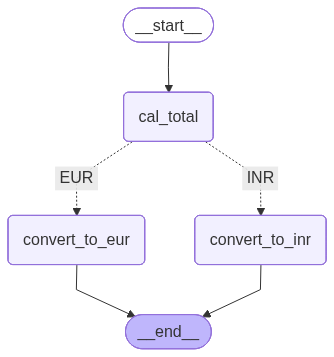

In [5]:
graph = builder.compile()
from IPython.display import Image , display



display(Image(graph.get_graph().draw_mermaid_png()))

In [6]:
graph.invoke({"amount_usd": 100,"target_currency": "EUR"})


{'amount_usd': 100,
 'total_usd': 108.0,
 'target_currency': 'EUR',
 'total': 97.2}